### Project 2: Regression (Binding Strength)

Goal: Predict HOW STRONGLY the protein binds (Continuous score 0.0–1.0).

To discover: Quantitative rules.

Model learns not just if a motif exists, but how perfect the match is, if there are multiple sites, or if flanking regions (GC content) boost binding affinity.

Model Architecture: 1D CNN (similar to above, but different output).

Input: One-hot encoded sequence (N, 4, 201) + optional gc_content.

Layer 1: Conv1D (learns motifs).
Activation: ReLU.

Pooling: GlobalMaxPooling1D or GlobalAveragePooling1D.

Output Layer: Dense(1) with Linear (no activation) function.

Loss Function: Mean Squared Error (MSE).

Metric: Pearson Correlation or MSE.

In [ ]:
# checking is CSV file is loading correctly
# What columns are there.

import pandas as pd
import numpy as np
import matplotlib.pyplot as np
import seaborn as sns

# data
df = pd.read_csv('project2_regression.csv')

# dimensions and first rows
print(f"Shape: {df.shape}")
print(df.head())

# data types and non-null counts
print(df.info())   

Shape: (8468, 3)
                                            sequence  score_norm  gc_content
0  GACAGGGCAGTGGGAAGGGGGGCGCGCGGGTGGCGGCCCCAACAGA...    0.867706   73.631841
1  GGCTCACCCGGGCCTCCTGATCGACAGGCTGTTCTCTGCACCCCGT...    0.792862   74.626866
2  CAGTGACACTACTGCTTGAACCCTAAGCCTTAGCTCTAAAACCGCG...    0.933032   54.228856
3  GCTTAAATGATAGAAAACCACGTGTTAGCCTTCTAGGATGTGTTCC...    0.609194   62.686567
4  GAGAATGAAAATTAGCGTTTGTTTGTCTAAGAGCTCTAAGACGGGG...    0.938367   61.194030
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8468 entries, 0 to 8467
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sequence    8468 non-null   object 
 1   score_norm  8468 non-null   float64
 2   gc_content  8468 non-null   float64
dtypes: float64(2), object(1)
memory usage: 198.6+ KB
None


Conclusions for data uality: 8,468 samples, no missing values, data types are correct (object for sequence, float64 for targets).Score range: 0.0-1.0 OK. 

Unique lengths: [201]
Expected length (e.g., 201): 201
Rows with invalid bases: 4236


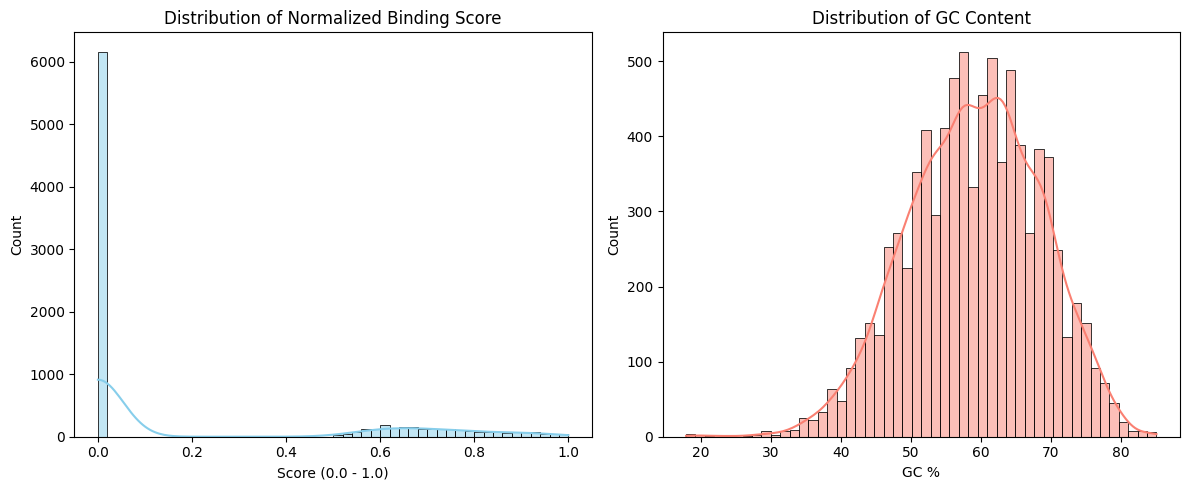

In [2]:
# Checking for accidental "N" in sequences.tsv

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sequences Length Consistency
seq_lengths = df['sequence'].str.len()
print(f"Unique lengths: {seq_lengths.unique()}")
print(f"Expected length (e.g., 201): {seq_lengths.mode()[0]}")

# 2. Invalid Bases? anything except ACTG
valid_bases = set('ACGT')
def has_invalid(seq):
    return not set(seq.upper()).issubset(valid_bases)

invalid_count = df['sequence'].apply(has_invalid).sum()
print(f"Rows with invalid bases: {invalid_count}")

# 3. Visualization of Target and GC Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Target Distribution
sns.histplot(df['score_norm'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Normalized Binding Score')
axes[0].set_xlabel('Score (0.0 - 1.0)')

# GC Content Distribution
sns.histplot(df['gc_content'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of GC Content')
axes[1].set_xlabel('GC %')

plt.tight_layout()
plt.show()   

In [4]:
import numpy as np
import pandas as pd

def print_text_histogram(data, title, bins=20, width=50):
    """Prints a horizontal histogram to the console."""
    counts, bin_edges = np.histogram(data, bins=bins)
    max_count = counts.max()
    
    print(f"\n--- {title} ---")
    print(f"Total Samples: {len(data):,}")
    print(f"Min: {data.min():.4f} | Max: {data.max():.4f} | Mean: {data.mean():.4f}")
    print("-" * (width + 25))
    
    for i, count in enumerate(counts):
        bar_len = int((count / max_count) * width)
        bar = '#' * bar_len
        label = f"{bin_edges[i]:.2f}-{bin_edges[i+1]:.2f}"
        print(f"{label:>12} | {bar:<{width}} ({count})")
    print("-" * (width + 25))

# Load your data
df = pd.read_csv('project2_regression.csv')

# 1. Histogram of Raw Scores (to see the zeros)
print_text_histogram(df['score_norm'], "Distribution of Normalized Scores (RAW)")

# 2. Histogram of Non-Zero Scores (to see the actual binding distribution)
non_zero_scores = df[df['score_norm'] > 0]['score_norm']
if len(non_zero_scores) > 0:
    print_text_histogram(non_zero_scores, "Distribution of Non-Zero Scores")
else:
    print("\nNo non-zero scores found!")

# 3. GC Content Distribution
print_text_histogram(df['gc_content'], "Distribution of GC Content")   


--- Distribution of Normalized Scores (RAW) ---
Total Samples: 8,468
Min: 0.0000 | Max: 1.0000 | Mean: 0.1974
---------------------------------------------------------------------------
   0.00-0.05 | ################################################## (6160)
   0.05-0.10 |                                                    (0)
   0.10-0.15 |                                                    (0)
   0.15-0.20 |                                                    (0)
   0.20-0.25 |                                                    (0)
   0.25-0.30 |                                                    (0)
   0.30-0.35 |                                                    (0)
   0.35-0.40 |                                                    (0)
   0.40-0.45 |                                                    (0)
   0.45-0.50 |                                                    (0)
   0.50-0.55 |                                                    (92)
   0.55-0.60 | ##                      